# Delhi PM2.5 Forecasting — SIH26082 (Air Pollution–Weather Coupled Forecasting System)

This notebook improves on the first version in three ways that map directly to the problem statement's objectives:

1. **Objective 1 (Integrate Data):** uses `delhi_master_dataset.csv`, which merges PM2.5 with meteorological features (temperature, humidity, wind speed/direction, pressure, precipitation, ventilation index) — not just PM2.5 lags.
2. **Objective 2 (Predict Spikes):** adds a severe-episode **classification** target (will PM2.5 cross a CPCB "Very Poor/Severe" breakpoint in the next few hours?), in addition to plain regression.
3. **Evaluation integrity:** uses a **chronological** train/val/test split (no shuffling) plus a **naive persistence baseline**, so reported metrics are trustworthy for a time series problem, and forecasts multiple horizons (1h / 6h / 12h / 24h ahead).

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    precision_score, recall_score, f1_score, confusion_matrix, classification_report
)
from xgboost import XGBRegressor, XGBClassifier

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

## 1. Load the coupled (PM2.5 + weather) dataset

In [29]:
df = pd.read_csv("delhi_master_dataset.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(16630, 28)
['datetime', 'location', 'latitude', 'longitude', 'pm25', 'hour', 'dow', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'pm25_lag_1h', 'pm25_lag_3h', 'pm25_lag_6h', 'pm25_lag_12h', 'pm25_lag_24h', 'pm25_rolling_mean_3h', 'pm25_rolling_mean_6h', 'pm25_rolling_mean_24h', 'pm25_rolling_std_6h', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'wind_direction_10m', 'surface_pressure', 'precipitation', 'temperature_change_3h', 'ventilation_index']


,datetime,location,latitude,longitude,pm25,hour,dow,hour_sin,hour_cos,dow_sin,dow_cos,pm25_lag_1h,pm25_lag_3h,pm25_lag_6h,pm25_lag_12h,pm25_lag_24h,pm25_rolling_mean_3h,pm25_rolling_mean_6h,pm25_rolling_mean_24h,pm25_rolling_std_6h,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,temperature_change_3h,ventilation_index
0,2026-08-05 10:00:00+05:30,Air Check,28.623056,77.234167,62.7,10,2,5.000000e-01,-0.866025,0.974928,-0.222521,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.3,69,4.7,310,976.1,0.0,NaN,NaN
1,2026-08-05 11:00:00+05:30,Air Check,28.623056,77.234167,56.8,11,2,2.588190e-01,-0.965926,0.974928,-0.222521,62.7,NaN,NaN,NaN,NaN,62.700000,NaN,NaN,NaN,31.6,71,3.6,300,976.2,0.1,NaN,NaN
2,2026-08-05 12:00:00+05:30,Air Check,28.623056,77.234167,68.6,12,2,1.224647e-16,-1.000000,0.974928,-0.222521,56.8,NaN,NaN,NaN,NaN,59.750000,NaN,NaN,NaN,31.1,72,4.4,289,975.0,0.1,NaN,NaN
3,2026-08-05 13:00:00+05:30,Air Check,28.623056,77.234167,71.5,13,2,-2.588190e-01,-0.965926,0.974928,-0.222521,68.6,62.7,NaN,NaN,NaN,62.700000,62.7,NaN,5.900000,31.9,69,5.0,300,974.7,0.0,0.6,5.600
4,2026-08-05 14:00:00+05:30,Air Check,28.623056,77.234167,69.9,14,2,-5.000000e-01,-0.866025,0.974928,-0.222521,71.5,56.8,NaN,NaN,NaN,65.633333,64.9,NaN,6.524314,31.8,68,5.7,294,973.7,0.0,0.2,5.928


In [30]:
print(df.info())
print()
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 16630 entries, 0 to 16629
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   datetime               16630 non-null  str    
 1   location               16630 non-null  str    
 2   latitude               16630 non-null  float64
 3   longitude              16630 non-null  float64
 4   pm25                   15747 non-null  float64
 5   hour                   16630 non-null  int64  
 6   dow                    16630 non-null  int64  
 7   hour_sin               16630 non-null  float64
 8   hour_cos               16630 non-null  float64
 9   dow_sin                16630 non-null  float64
 10  dow_cos                16630 non-null  float64
 11  pm25_lag_1h            15723 non-null  float64
 12  pm25_lag_3h            15675 non-null  float64
 13  pm25_lag_6h            15603 non-null  float64
 14  pm25_lag_12h           15459 non-null  float64
 15  pm25_lag_24h 

## 2. Exploratory analysis

Correlation heatmap now includes the weather variables, so we can actually see which meteorological
drivers (wind speed, ventilation index, humidity, temperature) relate to PM2.5 — this is the
"coupling" the problem statement asks for.

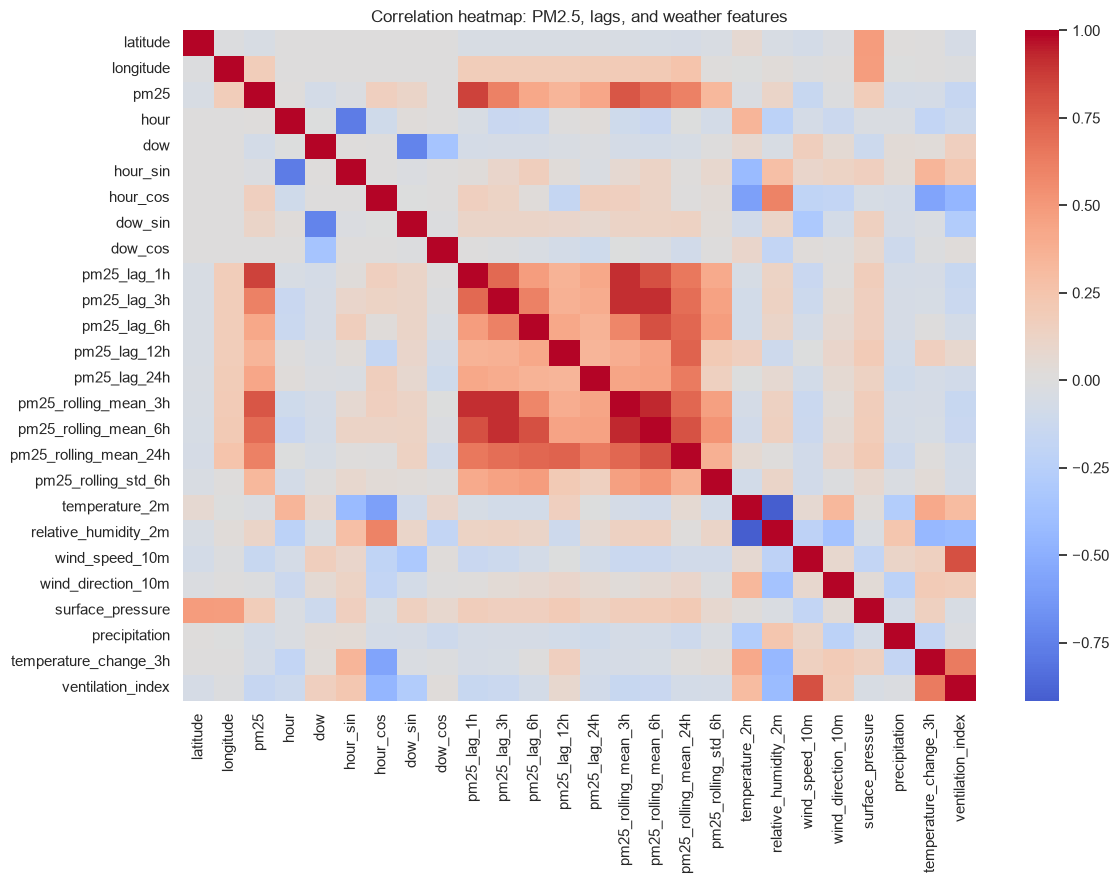

In [31]:
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm", center=0)
plt.title("Correlation heatmap: PM2.5, lags, and weather features")
plt.tight_layout()
plt.show()

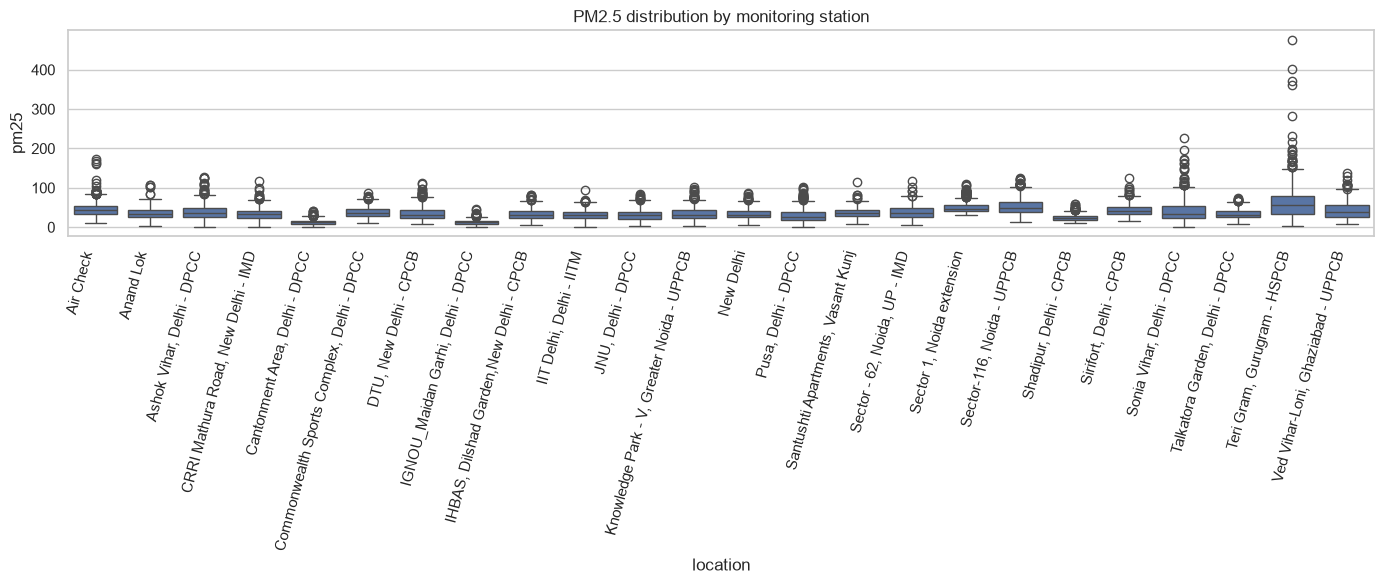

In [32]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x="location", y="pm25")
plt.xticks(rotation=75, ha="right")
plt.title("PM2.5 distribution by monitoring station")
plt.tight_layout()
plt.show()

## 3. Clean and sort

Convert `datetime`, sort by `location` then time, and interpolate missing values **within each
location's own time series** (not across locations, and not across the whole dataframe blindly).
Both PM2.5 and the weather columns get this treatment — edge NaNs (start/end of a station's series)
are forward/back-filled since linear interpolation can't extrapolate.

In [33]:
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values(["location", "datetime"]).reset_index(drop=True)

weather_cols = [
    "temperature_2m", "relative_humidity_2m", "wind_speed_10m", "wind_direction_10m",
    "surface_pressure", "precipitation", "temperature_change_3h", "ventilation_index",
]

df["pm25"] = (
    df.groupby("location")["pm25"]
      .transform(lambda x: x.interpolate(method="linear").ffill().bfill())
)

for c in weather_cols:
    df[c] = (
        df.groupby("location")[c]
          .transform(lambda x: x.interpolate(method="linear").ffill().bfill())
    )

print(df.isnull().sum())

datetime                    0
location                    0
latitude                    0
longitude                   0
pm25                        0
hour                        0
dow                         0
hour_sin                    0
hour_cos                    0
dow_sin                     0
dow_cos                     0
pm25_lag_1h               907
pm25_lag_3h               955
pm25_lag_6h              1027
pm25_lag_12h             1171
pm25_lag_24h             1459
pm25_rolling_mean_3h      812
pm25_rolling_mean_6h      902
pm25_rolling_mean_24h    1084
pm25_rolling_std_6h       902
temperature_2m              0
relative_humidity_2m        0
wind_speed_10m              0
wind_direction_10m          0
surface_pressure            0
precipitation               0
temperature_change_3h       0
ventilation_index           0
dtype: int64


## 4. Multi-horizon forecast targets

Objective 2 asks for a forecasting system, not just a next-hour estimate. We build targets for
four lead times: **1h, 6h, 12h, 24h** ahead, all computed *within* each location's series so we
never leak PM2.5 from one station into another's target.

In [34]:
HORIZONS = {"1h": 1, "6h": 6, "12h": 12, "24h": 24}

for name, h in HORIZONS.items():
    df[f"target_pm25_{name}"] = df.groupby("location")["pm25"].shift(-h)

df[[f"target_pm25_{n}" for n in HORIZONS]].isnull().sum()

target_pm25_1h      24
target_pm25_6h     144
target_pm25_12h    288
target_pm25_24h    576
dtype: int64

## 5. Feature set

Same lag/rolling/time features as before, **plus the weather variables**. `location` is one-hot
encoded so the model can still learn station-specific baselines (e.g. traffic-heavy vs green
areas) without treating it as an ordinal number.

In [35]:
feature_cols = [
    "latitude", "longitude", "pm25",
    "pm25_lag_1h", "pm25_lag_3h", "pm25_lag_6h", "pm25_lag_12h", "pm25_lag_24h",
    "pm25_rolling_mean_3h", "pm25_rolling_mean_6h", "pm25_rolling_mean_24h", "pm25_rolling_std_6h",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "temperature_2m", "relative_humidity_2m", "wind_speed_10m", "wind_direction_10m",
    "surface_pressure", "precipitation", "temperature_change_3h", "ventilation_index",
]

X_full = pd.get_dummies(df[feature_cols + ["location"]], columns=["location"], drop_first=True, dtype=int)
print(X_full.shape)
X_full.head()

(16630, 47)


,latitude,longitude,pm25,pm25_lag_1h,pm25_lag_3h,pm25_lag_6h,pm25_lag_12h,pm25_lag_24h,pm25_rolling_mean_3h,pm25_rolling_mean_6h,pm25_rolling_mean_24h,pm25_rolling_std_6h,hour_sin,hour_cos,dow_sin,dow_cos,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation,temperature_change_3h,ventilation_index,location_Anand Lok,"location_Ashok Vihar, Delhi - DPCC","location_CRRI Mathura Road, New Delhi - IMD","location_Cantonment Area, Delhi - DPCC","location_Commonwealth Sports Complex, Delhi - DPCC","location_DTU, New Delhi - CPCB","location_IGNOU_Maidan Garhi, Delhi - DPCC","location_IHBAS, Dilshad Garden,New Delhi - CPCB","location_IIT Delhi, Delhi - IITM","location_JNU, Delhi - DPCC","location_Knowledge Park - V, Greater Noida - UPPCB",location_New Delhi,"location_Pusa, Delhi - DPCC","location_Santushti Apartments, Vasant Kunj","location_Sector - 62, Noida, UP - IMD","location_Sector 1, Noida extension","location_Sector-116, Noida - UPPCB","location_Shadipur, Delhi - CPCB","location_Sirifort, Delhi - CPCB","location_Sonia Vihar, Delhi - DPCC","location_Talkatora Garden, Delhi - DPCC","location_Teri Gram, Gurugram - HSPCB","location_Ved Vihar-Loni, Ghaziabad - UPPCB"
0,28.623056,77.234167,62.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000e-01,-0.866025,0.974928,-0.222521,31.3,69,4.7,310,976.1,0.0,0.6,5.600,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,28.623056,77.234167,56.8,62.7,NaN,NaN,NaN,NaN,62.700000,NaN,NaN,NaN,2.588190e-01,-0.965926,0.974928,-0.222521,31.6,71,3.6,300,976.2,0.1,0.6,5.600,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,28.623056,77.234167,68.6,56.8,NaN,NaN,NaN,NaN,59.750000,NaN,NaN,NaN,1.224647e-16,-1.000000,0.974928,-0.222521,31.1,72,4.4,289,975.0,0.1,0.6,5.600,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,28.623056,77.234167,71.5,68.6,62.7,NaN,NaN,NaN,62.700000,62.7,NaN,5.900000,-2.588190e-01,-0.965926,0.974928,-0.222521,31.9,69,5.0,300,974.7,0.0,0.6,5.600,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,28.623056,77.234167,69.9,71.5,56.8,NaN,NaN,NaN,65.633333,64.9,NaN,6.524314,-5.000000e-01,-0.866025,0.974928,-0.222521,31.8,68,5.7,294,973.7,0.0,0.2,5.928,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 6. Chronological split (fixes a data-leakage bug from v1)

The earlier version used `train_test_split(..., shuffle default=True)`, which randomly mixes
timestamps between train and test. Because lag/rolling features make neighbouring hours highly
correlated, that silently leaks information and inflates the score.

Here we split **by calendar time**: the earliest 70% of timestamps train, the next 15% validate,
the last 15% test — the same cutoff is used for every station, so no station is anomalously
missing from a split.

In [36]:
cutoff_train = df["datetime"].quantile(0.70)
cutoff_val = df["datetime"].quantile(0.85)

train_mask = df["datetime"] <= cutoff_train
val_mask = (df["datetime"] > cutoff_train) & (df["datetime"] <= cutoff_val)
test_mask = df["datetime"] > cutoff_val

print("Train:", train_mask.sum(), df.loc[train_mask, "datetime"].min(), "->", df.loc[train_mask, "datetime"].max())
print("Val:  ", val_mask.sum(), df.loc[val_mask, "datetime"].min(), "->", df.loc[val_mask, "datetime"].max())
print("Test: ", test_mask.sum(), df.loc[test_mask, "datetime"].min(), "->", df.loc[test_mask, "datetime"].max())

Train: 11660 2026-08-05 10:00:00+05:30 -> 2026-08-25 15:00:00+05:30
Val:   2496 2026-08-25 16:00:00+05:30 -> 2026-08-29 23:00:00+05:30
Test:  2474 2026-08-30 00:00:00+05:30 -> 2026-09-04 09:00:00+05:30


## 7. Train + evaluate a model per horizon, against a naive baseline

The baseline is "PM2.5 at t+h = PM2.5 now" (persistence). Any model that doesn't clearly beat this
isn't earning its complexity — this is the check the original notebook was missing entirely.

Median imputation for any remaining NaNs in the feature matrix is fit **on the training split
only** and applied to val/test, so no split boundary information leaks backwards either.

In [37]:
def train_eval_horizon(horizon_name):
    target_col = f"target_pm25_{horizon_name}"
    valid = df[target_col].notna()

    X = X_full[valid]
    y = df.loc[valid, target_col]
    tr = train_mask[valid]
    va = val_mask[valid]
    te = test_mask[valid]

    train_median = X[tr].median()
    X_imputed = X.fillna(train_median)

    X_train, y_train = X_imputed[tr], y[tr]
    X_val, y_val = X_imputed[va], y[va]
    X_test, y_test = X_imputed[te], y[te]

    model = XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        eval_metric="mae",
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )
    pred = model.predict(X_test)

    naive_pred = df.loc[X_test.index, "pm25"]  # "no change" baseline

    result = {
        "horizon": horizon_name,
        "model_mae": mean_absolute_error(y_test, pred),
        "model_rmse": np.sqrt(mean_squared_error(y_test, pred)),
        "model_r2": r2_score(y_test, pred),
        "baseline_mae": mean_absolute_error(y_test, naive_pred),
        "baseline_rmse": np.sqrt(mean_squared_error(y_test, naive_pred)),
    }
    return model, result, (y_test, pred)

results = []
models = {}
preds = {}
for h in HORIZONS:
    model, res, pr = train_eval_horizon(h)
    models[h] = model
    preds[h] = pr
    results.append(res)

results_df = pd.DataFrame(results)
results_df

,horizon,model_mae,model_rmse,model_r2,baseline_mae,baseline_rmse
0,1h,4.574266,6.540056,0.801969,4.110073,6.188947
1,6h,9.033627,12.003790,0.346378,10.170544,13.821510
2,12h,10.654920,15.249916,-0.035379,11.673088,15.405286
3,24h,11.236065,15.626005,-0.136970,9.425617,13.773228


**How to read this table:** `model_mae`/`model_rmse` should be clearly lower than
`baseline_mae`/`baseline_rmse` at every horizon. If they're close at 1h, that's expected (PM2.5
barely changes hour to hour). The gap should widen at 12h/24h, where persistence gets much worse
but the model can still use weather + time-of-day signal.

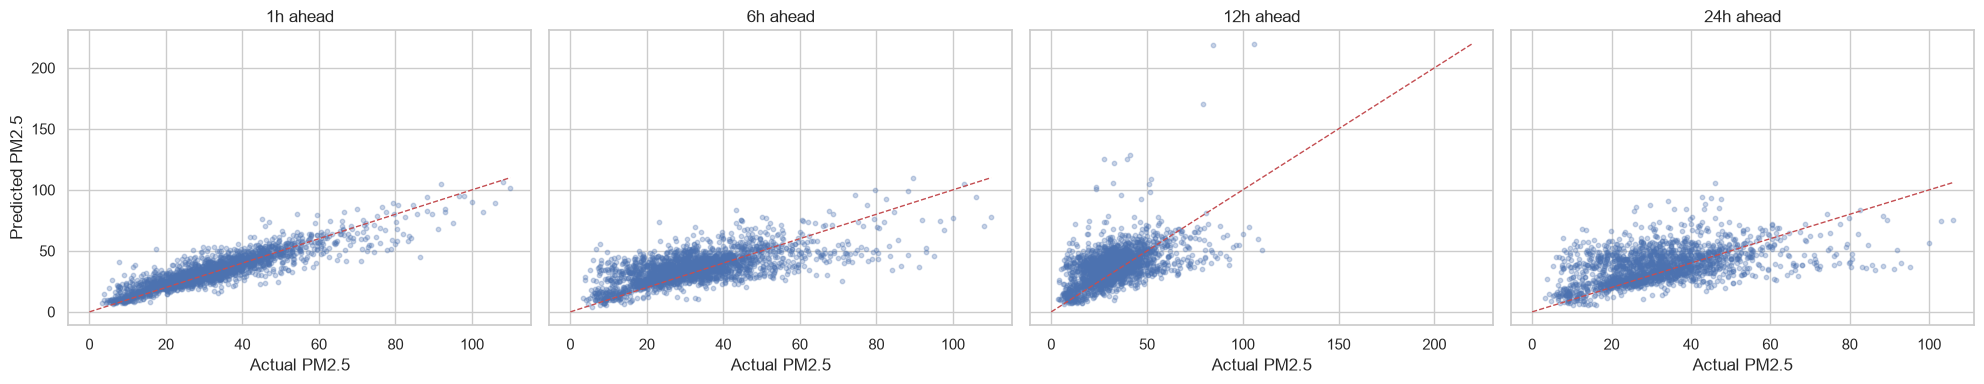

In [38]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(20, 4), sharey=True)
for ax, h in zip(axes, HORIZONS):
    y_test, pred = preds[h]
    ax.scatter(y_test, pred, alpha=0.3, s=10)
    lims = [0, max(y_test.max(), pred.max())]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_title(f"{h} ahead")
    ax.set_xlabel("Actual PM2.5")
axes[0].set_ylabel("Predicted PM2.5")
plt.tight_layout()
plt.show()

## 8. Feature importance (which signals actually drive the forecast)

Useful both for the report and for sanity-checking the model — if weather features never show up,
something's off; if they dominate, that's a good sign the "coupling" is real.

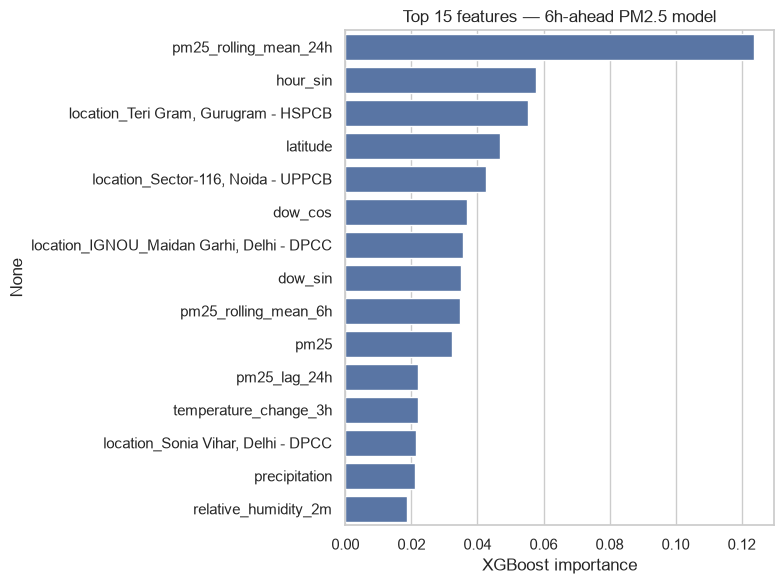

In [39]:
imp = pd.Series(models["6h"].feature_importances_, index=X_full.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 6))
sns.barplot(x=imp.values, y=imp.index)
plt.title("Top 15 features — 6h-ahead PM2.5 model")
plt.xlabel("XGBoost importance")
plt.tight_layout()
plt.show()

## 9. Severe-episode early warning (classification)

Objective 2/3 are about *warning* people before a smog episode, not just producing a continuous
number. CPCB's PM2.5 AQI breakpoints mark "Very Poor" starting at 121 µg/m³ and "Severe" at 250+.

**Important caveat about this specific dataset:** the current data only covers Aug–Sep (monsoon
season), when Delhi's air is comparatively clean — PM2.5 barely reaches "Poor" here, let alone
"Severe". So the fixed CPCB thresholds would produce almost no positive examples and an untrainable
classifier on this slice. Below we set the alert threshold as the **90th percentile of this
dataset's own PM2.5** so the pipeline is demonstrably correct end-to-end. Once winter data
(Oct–Jan, when real smog episodes happen) is added, switch `SEVERE_THRESHOLD` to a fixed CPCB
value (e.g. 200 or 250) — that's the version that should ship in the actual dashboard.

In [40]:
# Demo threshold: relative to this dataset's own distribution (data currently has no winter months).
# Replace with an absolute CPCB breakpoint (e.g. 200 or 250) once winter data is included.
SEVERE_THRESHOLD = df["pm25"].quantile(0.90)
print("Using SEVERE_THRESHOLD =", round(SEVERE_THRESHOLD, 1), "µg/m3 (90th percentile of current data)")

df["target_spike_6h"] = (df.groupby("location")["pm25"].shift(-6) >= SEVERE_THRESHOLD).astype(int)

valid = df["target_spike_6h"].notna()
Xc = X_full[valid].fillna(X_full[valid][train_mask[valid]].median())
yc = df.loc[valid, "target_spike_6h"]

tr, te = train_mask[valid], test_mask[valid]
X_train_c, y_train_c = Xc[tr], yc[tr]
X_test_c, y_test_c = Xc[te], yc[te]

print("Positive rate — train:", y_train_c.mean().round(4), " test:", y_test_c.mean().round(4))

pos_weight = (y_train_c == 0).sum() / max((y_train_c == 1).sum(), 1)

clf = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    scale_pos_weight=pos_weight, eval_metric="logloss",
)
clf.fit(X_train_c, y_train_c)
threshold=0.4
prob = clf.predict_proba(X_test_c)[:, 1]
    
pred_c = (prob >= threshold).astype(int)
    
precision = precision_score(y_test_c, pred_c, zero_division=0)
recall = recall_score(y_test_c, pred_c, zero_division=0)
f1 = f1_score(y_test_c, pred_c, zero_division=0)
    
print(
        f"Threshold={threshold}: "
        f"Precision={precision:.3f}, "
        f"Recall={recall:.3f}, "
        f"F1={f1:.3f}"
)

print(classification_report(y_test_c, pred_c, labels=[0, 1],
                             target_names=["not severe", "severe"], zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test_c, pred_c, labels=[0, 1]))

Using SEVERE_THRESHOLD = 61.0 µg/m3 (90th percentile of current data)
Positive rate — train: 0.0915  test: 0.0396
Threshold=0.4: Precision=0.172, Recall=0.459, F1=0.250
              precision    recall  f1-score   support

  not severe       0.98      0.91      0.94      2376
      severe       0.17      0.46      0.25        98

    accuracy                           0.89      2474
   macro avg       0.57      0.68      0.60      2474
weighted avg       0.94      0.89      0.91      2474

Confusion matrix:
 [[2159  217]
 [  53   45]]


With only ~1 month of (non-winter) data, don't over-trust these classification numbers — the
point of this section is that the pipeline (target creation → chronological split → imbalance
handling → evaluation) is correct and ready to retrain the moment a full pollution season of data
is available. Re-run this cell with a fixed CPCB threshold once that data exists.